# Week 9 - Artificial Neural Networks
## Exercise 1: Answer the quiz available via canvas.

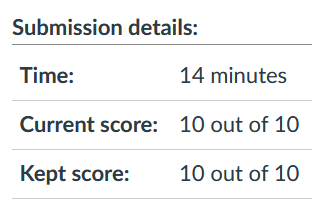

## Exercise 2: Install the required libraries and its dependences.

In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/48.7 kB ? eta -:--:--
     ---------------------------------------- 48.7/48.7 kB 1.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/385.0 MB ? eta -:--:--
   ---------------------------------------- 0.2/385.0 MB 3.7 MB/s eta 0:01:44
   ---------------------------------------- 0.5/385.0 MB 4.9 MB/s eta 0:01:19
   ---------------------------------------- 0.7/385.0 MB 5.2 MB/s eta 0:01:14
   ---------------------------------------- 0.7/385.0 MB 5.2 MB/s eta 0:01:14
   ---------------------------------------- 0.7/385.0 MB 3.3 MB/s eta 0:01:58
   ---------------------------------------- 0.9/385.0 MB 3.2 MB/s eta 0:02:01
   ---------------------------------------- 1.0/385.0 MB 3.1 MB/s eta 0:02:05
   ---------------------------------------- 1.1/385.0 MB 2.9 MB/s eta 0:02:14
   ---------------------------------------- 1.1/385.0 MB 2.6 MB/s eta 0:02:

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



   ----------------------------- ---------- 285.5/385.0 MB 1.7 MB/s eta 0:00:59
   ----------------------------- ---------- 285.6/385.0 MB 1.7 MB/s eta 0:00:59
   ----------------------------- ---------- 285.7/385.0 MB 1.7 MB/s eta 0:00:58
   ----------------------------- ---------- 285.7/385.0 MB 1.7 MB/s eta 0:00:58
   ----------------------------- ---------- 285.8/385.0 MB 1.7 MB/s eta 0:00:58
   ----------------------------- ---------- 285.9/385.0 MB 1.7 MB/s eta 0:00:58
   ----------------------------- ---------- 286.0/385.0 MB 1.7 MB/s eta 0:00:58
   ----------------------------- ---------- 286.0/385.0 MB 1.7 MB/s eta 0:00:58
   ----------------------------- ---------- 286.1/385.0 MB 1.7 MB/s eta 0:00:57
   ----------------------------- ---------- 286.2/385.0 MB 1.8 MB/s eta 0:00:57
   ----------------------------- ---------- 286.3/385.0 MB 1.7 MB/s eta 0:00:57
   ----------------------------- ---------- 286.3/385.0 MB 1.8 MB/s eta 0:00:57
   ----------------------------- ------

## Exercise 3: Initially we will start by importing the California housing dataset and perform some basic data analysis on it to get a good understanding of the features. The steps for that are:

### 1. Import the necessary libraries.

In [1]:
#EDA 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import fetch_california_housing

### 2. Load the dataset.

In [2]:
# Load the California housing dataset 
california_housing = fetch_california_housing() 
data = pd.DataFrame(data=np.c_[california_housing['data'], 
                    california_housing['target']], 
                    columns=california_housing['feature_names'] + ['target'])

### 3. Quick check the data header and perform some basic statistics

In [3]:
# Display the first few rows of the dataset 
print(data.head()) 

# Summary statistics of the numerical features 
print(data.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%       

### 4. We can perform some basic regression analysis to understand the relation between different features.

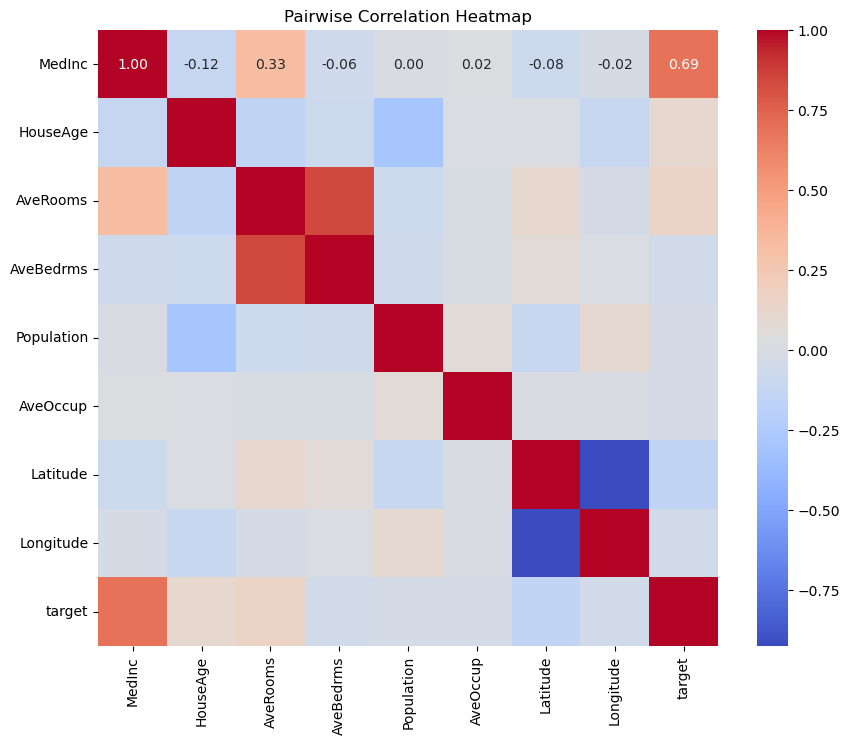

In [4]:
# Pairwise correlation heatmap 
correlation_matrix = data.corr() 
plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f") 
plt.title('Pairwise Correlation Heatmap') 
plt.show()

### 5. To get a good understanding of the target variable we can plot its histogram

D:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


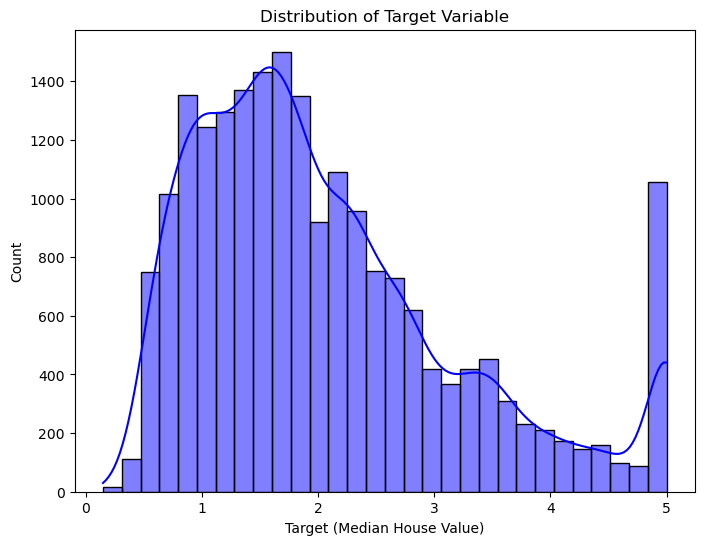

In [9]:
# Distribution of the target variable 
plt.figure(figsize=(8, 6)) 
sns.histplot(data['target'], bins=30, kde=True, color='blue') 
plt.title('Distribution of Target Variable') 
plt.xlabel('Target (Median House Value)') 
plt.show()

### 6. Based on the correlation matrix we can study the relation between some of the features and the target as follows:

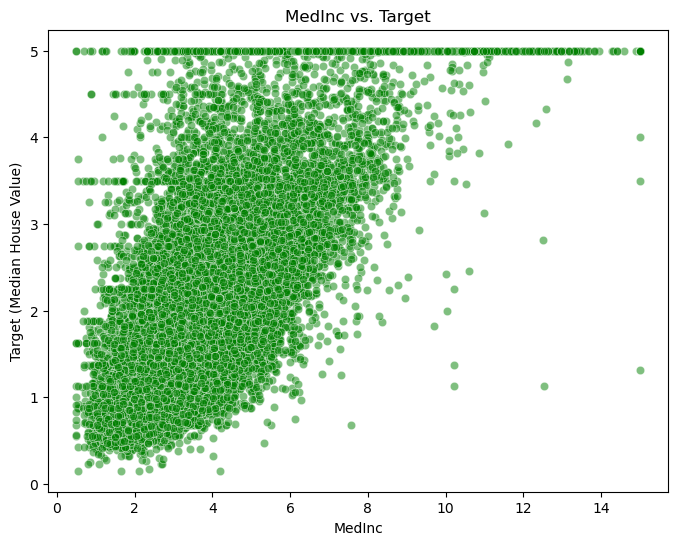

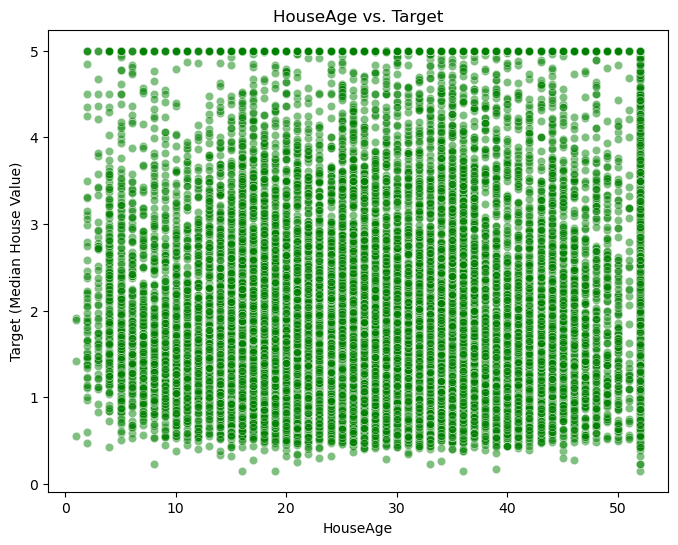

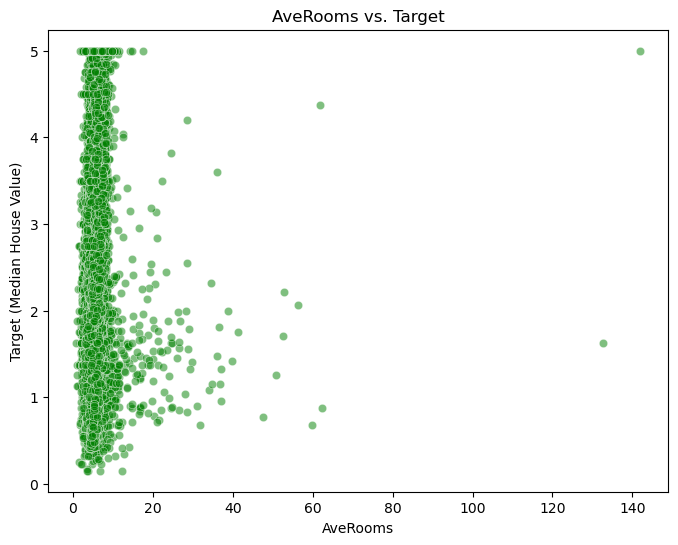

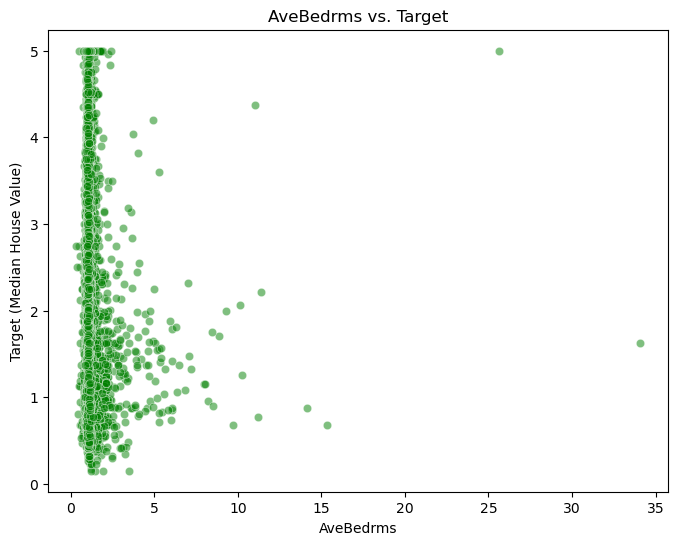

In [10]:
# Scatter plot of selected features against the target variable 
selected_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms'] 
for feature in selected_features: 
    plt.figure(figsize=(8, 6)) 
    sns.scatterplot(x=data[feature], y=data['target'], color='green', alpha=0.5) 
    plt.title(f'{feature} vs. Target') 
    plt.xlabel(feature) 
    plt.ylabel('Target (Median House Value)') 
    plt.show()
    

## Exercise 4: After performing the basic data analysis, we can now start to build a regression model and we will be using a MLP and compare its performance to ANN.

### 1. We will start by importing the libraries It is worth noting here that we will be using the MLP regressor from the SKlearn library.

In [12]:
from sklearn.datasets import fetch_california_housing 
from sklearn.metrics import mean_squared_error 
from sklearn.model_selection import train_test_split 
from sklearn.neural_network import MLPRegressor 
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import StandardScaler

### 2. We will be using the same dataset (California housing one), but we need to split it into train and test sets.

In [13]:
housing = fetch_california_housing() 
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42) 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

### 3. Now our datasets are ready, we can start working defining the model and the pipeline as follows:

In [16]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[25, 25, 25], random_state=42) 

pipeline = make_pipeline(StandardScaler(), mlp_reg)

### 4. The next step is to train the model and use it for predication.

In [17]:
pipeline.fit(X_train, y_train) 
y_pred = pipeline.predict(X_valid)

D:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 5. We can assess the performance of the predication using the RMSE matric.

In [19]:
rmse = mean_squared_error(y_valid, y_pred, squared=False) # about 0.64 
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.6409306726990712


### 6. We can also visualise the performance by comparing the predicted values with the actual values.

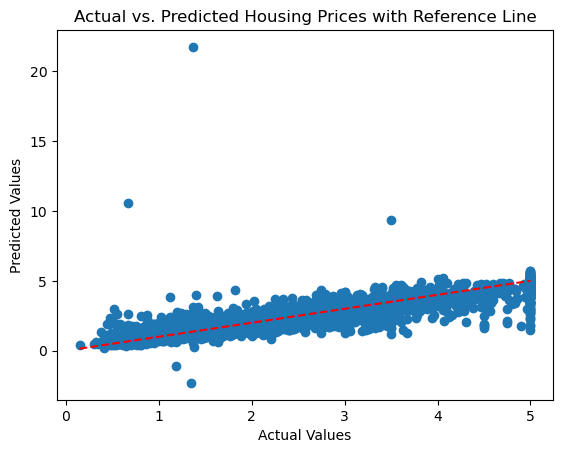

In [20]:
# Plot predicted vs. actual values 
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], linestyle='--', color='red') 
plt.scatter(y_valid, y_pred) 
plt.xlabel('Actual Values') 
plt.ylabel('Predicted Values') 
plt.title('Actual vs. Predicted Housing Prices with Reference Line') 
plt.show()

## Exercise 5: In this exercise we will be using a simple ANN for the regression task and compare its performance to the MLP model.

### 1. We will start by importing the libraries, It is worth noting here that we will be using the karas library.

In [21]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error 
from keras.models import Sequential 
from keras.layers import Dense 
from keras.optimizers import Adam

### 2. We will be using the same dataset (California housing one), but we need to split it into train and test sets.

In [22]:
# Load the California housing dataset 
california_housing = fetch_california_housing() 
data = pd.DataFrame(data=np.c_[california_housing['data'], 
                    california_housing['target']], 
                    columns=california_housing['feature_names'] + ['target'])

### 3. We will be using all the dataset features as an input and the house price as an output(target):

In [23]:
# Select features and target variable 
X = data.drop('target', axis=1) 
y = data['target']

### 4. Split the dataset it into train and test sets and scale the training set. The following script would split it into 80% train and 20% test which is determined by

In [25]:
# Split the dataset into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

# Standardize the features 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

### 5. Define the ANN model and compile it.

In [26]:
# Build the neural network model 
model = Sequential() 
model.add(Dense(units=512, input_dim=X_train.shape[1], activation='relu')) 
model.add(Dense(units=1, activation='linear')) # Linear activation for regression 

# Compile the model 
model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 6. Now our ANN is ready, and we can training it using the scaled training data

In [27]:
# Train the model 
model.fit(X_train_scaled, y_train, epochs=100, batch_size=128, 
          validation_data=(X_test_scaled, y_test), verbose=1)

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.0325 - val_loss: 0.5916
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5299 - val_loss: 0.4543
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4338 - val_loss: 0.4177
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3994 - val_loss: 0.4136
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4151 - val_loss: 0.3955
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4365 - val_loss: 0.3895
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3776 - val_loss: 0.3703
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3471 - val_loss: 0.3698
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3794 - val_loss: 0.3632
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3401 - val_loss: 0.3817
Epoch 11/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3633 - val_loss: 0.3831
Epoch 12/100
129/129 ━━━━━━━━━━━━━━━━━━━━

### 7. To use the ANN for prediction we use:

In [28]:
# Make predictions on the test set 
y_pred = model.predict(X_test_scaled)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### 8. Evaluate the prediction we use:

In [29]:
# Evaluate the model 
rmse = mean_squared_error(y_test, y_pred, squared=False) #about 0.53 
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.5330274685738086


### 9. Visualise the predication accuracy:

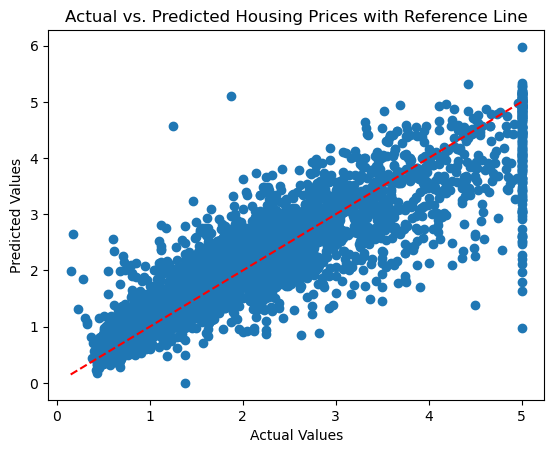

In [31]:
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.scatter(y_test, y_pred) 
plt.xlabel('Actual Values') 
plt.ylabel('Predicted Values') 
plt.title('Actual vs. Predicted Housing Prices with Reference Line') 
plt.show()

## Exercise 6: In this exercise we will be experimenting on different dataset size to asses the importance of collecting data for AI models. To do so we will change the train test split to have 30,50 % test split by changing the following:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Experiment with the 3 different splits and record the results

C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.5421 - val_loss: 0.6467
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6245 - val_loss: 0.4764
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4673 - val_loss: 0.4230
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4081 - val_loss: 0.4060
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4113 - val_loss: 0.3968
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3895 - val_loss: 0.3793
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3817 - val_loss: 0.3715
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3638 - val_loss: 0.3874
Epoch 9/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3651 - val_loss: 0.3706
Epoch 10/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3703 - val_loss: 0.3537
Epoch 11/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3432 - val_loss: 0.3539
Epoch 12/100
113/113 ━━━━━━━━━━━━━━━━━━━━

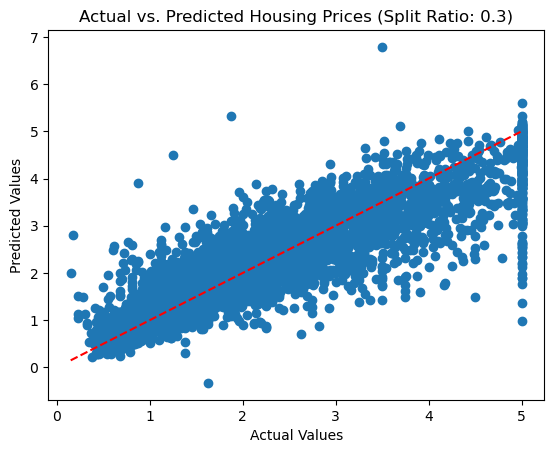

Epoch 1/100


C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.6400 - val_loss: 0.7078
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6367 - val_loss: 0.5482
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5128 - val_loss: 0.4709
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4449 - val_loss: 0.4839
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4774 - val_loss: 0.4107
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4162 - val_loss: 0.4008
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3997 - val_loss: 0.3914
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3773 - val_loss: 0.3847
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3861 - val_loss: 0.3796
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3823 - val_loss: 0.3736
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3706 - val_loss: 0.3744
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3670 - val_lo

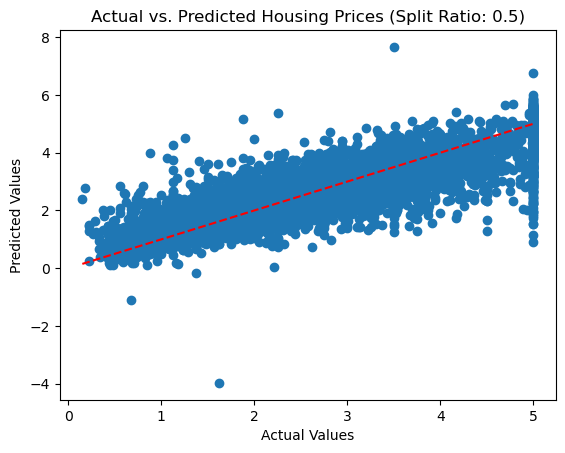

Epoch 1/100


C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 3.2431 - val_loss: 0.8441
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7550 - val_loss: 0.6836
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6148 - val_loss: 0.5450
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5089 - val_loss: 0.5136
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4422 - val_loss: 0.4329
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4271 - val_loss: 0.4434
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4317 - val_loss: 0.4086
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4030 - val_loss: 0.4211
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3895 - val_loss: 0.3904
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3749 - val_loss: 0.4165
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3927 - val_loss: 0.3940
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3744 - val_

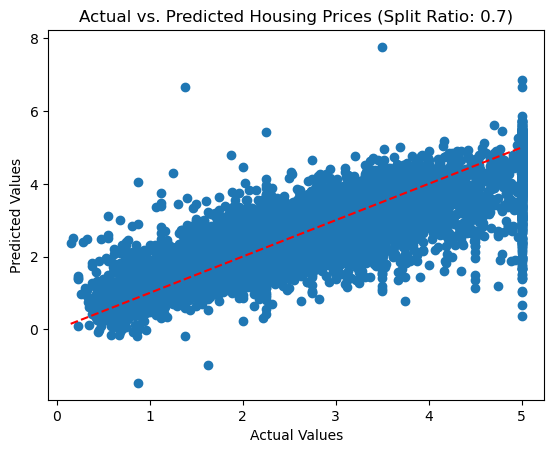

In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load the California housing dataset
california_housing = fetch_california_housing()
data = pd.DataFrame(data=np.c_[california_housing['data'], california_housing['target']],
                    columns=california_housing['feature_names'] + ['target'])

# Select features and target variable
X = data.drop('target', axis=1)
y = data['target']

def train_and_evaluate(X_train, X_test, y_train, y_test):
  # Standardize the features
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # Build the neural network model
  model = Sequential()
  model.add(Dense(units=512, input_dim=X_train.shape[1], activation='relu'))
  model.add(Dense(units=1, activation='linear'))  # Linear activation for regression

  # Compile the model
  model.compile(optimizer='adam', loss='mean_squared_error')

  # Train the model
  model.fit(X_train_scaled, y_train, epochs=100, batch_size=128,
            validation_data=(X_test_scaled, y_test), verbose=1)

  # Make predictions on the test set
  y_pred = model.predict(X_test_scaled)

  # Evaluate the model (RMSE)
  rmse = mean_squared_error(y_test, y_pred, squared=False)
  return y_pred, rmse

# Experiment with different train-test splits
split_ratios = [0.3, 0.5, 0.7]  # Example split ratios (70/30, 50/50, 30/70)

for split_ratio in split_ratios:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split_ratio, random_state=42)

  # Train and evaluate, returning both y_pred and rmse
  y_pred, rmse = train_and_evaluate(X_train, X_test, y_train, y_test)

  print(f"Split Ratio: {split_ratio} \nEvaluation Metric: Root Mean Squared Error (RMSE) \nMetric Value: {rmse}")

  # Plot predictions vs actual values for each split
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
  plt.scatter(y_test, y_pred) 
  plt.xlabel('Actual Values') 
  plt.ylabel('Predicted Values') 
  plt.title(f'Actual vs. Predicted Housing Prices (Split Ratio: {split_ratio})')
  plt.show()
  

## Exercise 7: Update the ANN model to have 256, then 512, and finally 1024 units and observe and record the change in the predication accuracy and the time taken to run the script. The part that would need changing to do so is:

In [ ]:
model = Sequential() 
model.add(Dense(units=512, input_dim=X_train.shape[1], activation='relu')) 
model.add(Dense(units=1, activation='linear')) # Linear activation for

Epoch 1/100


C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.5595 - val_loss: 0.6771
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6205 - val_loss: 0.5100
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4600 - val_loss: 0.4482
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4255 - val_loss: 0.4289
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3949 - val_loss: 0.4016
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4090 - val_loss: 0.3928
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3876 - val_loss: 0.3883
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3851 - val_loss: 0.3798
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3778 - val_loss: 0.3738
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3628 - val_loss: 0.3713
Epoch 11/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3679 - val_loss: 0.3624
Epoch 12/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

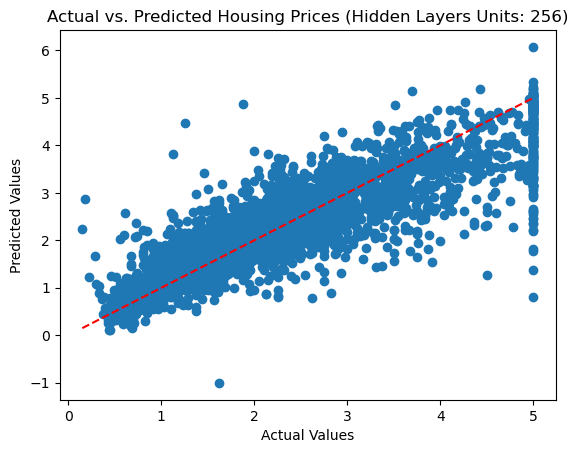

Epoch 1/100


C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.3543 - val_loss: 0.6107
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5652 - val_loss: 0.5232
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4928 - val_loss: 0.4183
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4019 - val_loss: 0.4005
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3830 - val_loss: 0.3845
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3946 - val_loss: 0.3772
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3576 - val_loss: 0.3754
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3538 - val_loss: 0.3734
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3650 - val_loss: 0.3567
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3453 - val_loss: 0.3558
Epoch 11/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3547 - val_loss: 0.3509
Epoch 12/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

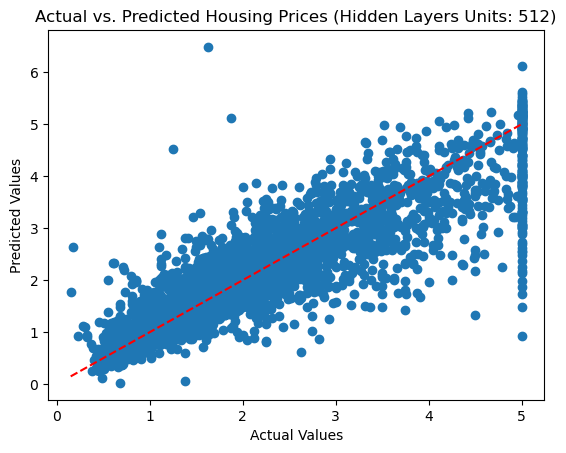

Epoch 1/100


C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.0851 - val_loss: 0.5481
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4972 - val_loss: 0.4310
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4157 - val_loss: 0.3998
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3920 - val_loss: 0.3875
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3860 - val_loss: 0.3843
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3688 - val_loss: 0.4013
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3645 - val_loss: 0.3629
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3602 - val_loss: 0.3655
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3360 - val_loss: 0.3488
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3415 - val_loss: 0.3493
Epoch 11/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3278 - val_loss: 0.3497
Epoch 12/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

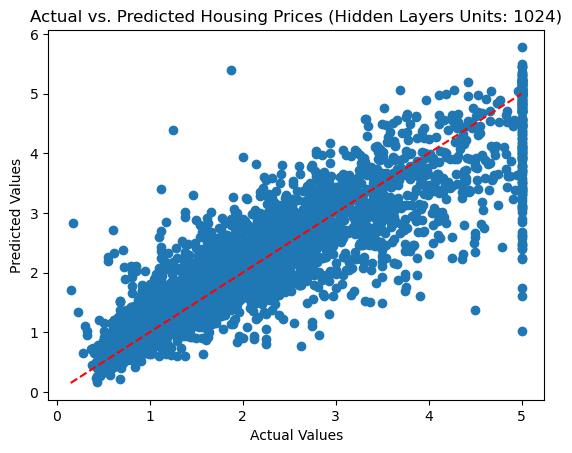

In [46]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import time

# Load the California housing dataset
california_housing = fetch_california_housing()
data = pd.DataFrame(data=np.c_[california_housing['data'], california_housing['target']],
                    columns=california_housing['feature_names'] + ['target'])

# Select features and target variable
X = data.drop('target', axis=1)
y = data['target']

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (performed outside the loop for efficiency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Experiment with different hidden layer units
hidden_layer_units = [256, 512, 1024]

for units in hidden_layer_units:
  start_time = time.time()  # Start time for training measurement

  # Build the neural network model
  model = Sequential()
  model.add(Dense(units=units, input_dim=X_train.shape[1], activation='relu'))
  model.add(Dense(units=1, activation='linear'))  # Linear activation for regression

  # Compile the model
  model.compile(optimizer='adam', loss='mean_squared_error')

  # Train the model
  model.fit(X_train_scaled, y_train, epochs=100, batch_size=128,
            validation_data=(X_test_scaled, y_test), verbose=1)

  # Make predictions on the test set
  y_pred = model.predict(X_test_scaled)

  # Evaluate the model (RMSE)
  rmse = mean_squared_error(y_test, y_pred, squared=False)

  # End time for training measurement
  end_time = time.time()
  training_time = end_time - start_time

  # Evaluation Output 
  print(f'''Hidden Layer Units: {units} 
  Root Mean Squared Error (RMSE): {rmse} 
  Training Time (seconds): {training_time}''') 

  # Visualization Output
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
  plt.scatter(y_test, y_pred) 
  plt.xlabel('Actual Values') 
  plt.ylabel('Predicted Values') 
  plt.title(f'Actual vs. Predicted Housing Prices (Hidden Layers Units: {units})')
  plt.show()


## Exercise 8: In this exercise we will use MLP for classification

### 1. Import the libraries.

In [47]:
from sklearn.neural_network import MLPClassifier 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score 
from sklearn.datasets import make_classification

### 2. Generate the dataset and split it X, y = make_classification(n_samples=1000

In [48]:
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42) 

# Split the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Scale the training dataset.

In [49]:
# Standardize the data (important for neural networks) 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

### 4. Define the MLP classifier.

In [50]:
# MLP Classifier 
mlp_classifier = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)

### 5. Trian it

In [51]:
# Train the MLP model 
mlp_classifier.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)

### 6. Use if for predicating.

In [52]:
# Make predictions on the test set 
mlp_predictions = mlp_classifier.predict(X_test)

### 7. Evaluate its accuracy.

In [53]:
# Evaluate the MLP model 
mlp_accuracy = accuracy_score(y_test, mlp_predictions) 
print("MLP Accuracy:", mlp_accuracy)

MLP Accuracy: 0.825


## Exercise 9: Experiment with different sizes for hidden layer and compare them in terms of accuracy and training time.

In [54]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
import time

# Parameters (modify as needed)
n_samples = 1000  # Number of samples
n_features = 20  # Number of features
n_classes = 2  # Number of classes
random_state = 42

# Define hidden layer size configurations to experiment with
hidden_layer_sizes_list = [(10,), (50,), (100,), (200,)]  # Example configurations

# Store results
results = []

for hidden_layer_sizes in hidden_layer_sizes_list:
  # Generate data
  X, y = make_classification(n_samples=n_samples, n_features=n_features, n_classes=n_classes, random_state=random_state)

  # Split the data into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

  # Standardize the data
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  # Start time for training measurement
  start_time = time.time()

  # MLP Classifier
  mlp_classifier = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, max_iter=1000, random_state=random_state)

  # Train the MLP model
  mlp_classifier.fit(X_train, y_train)

  # End time for training measurement
  end_time = time.time()
  training_time = end_time - start_time

  # Make predictions on the test set
  mlp_predictions = mlp_classifier.predict(X_test)

  # Evaluate the MLP model
  mlp_accuracy = accuracy_score(y_test, mlp_predictions)

  # Store results
  results.append({
      "Hidden Layer Sizes": hidden_layer_sizes,
      "Accuracy": mlp_accuracy,
      "Training Time (seconds)": training_time
  })

# Print results
print("Results:")
for result in results:
  print(result)


Results:
{'Hidden Layer Sizes': (10,), 'Accuracy': 0.87, 'Training Time (seconds)': 1.8428928852081299}
{'Hidden Layer Sizes': (50,), 'Accuracy': 0.83, 'Training Time (seconds)': 2.110511541366577}
{'Hidden Layer Sizes': (100,), 'Accuracy': 0.815, 'Training Time (seconds)': 2.250866651535034}
{'Hidden Layer Sizes': (200,), 'Accuracy': 0.805, 'Training Time (seconds)': 2.6791789531707764}


## Exercise 10: In this exercise, we will use ANN for the classification.

### 1. Import the ANN libraries.

In [55]:
from keras.models import Sequential 
from keras.layers import Dense

### 2. Define the model and compile it.

In [56]:
# Create a simple ANN model 
ann_model = Sequential() 
ann_model.add(Dense(100, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(1, activation='sigmoid')) 

# Compile the model 
ann_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. Train the ANN for 10 epochs

In [57]:
# Train the ANN model 
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5693 - loss: 0.6735
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7987 - loss: 0.5271
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8356 - loss: 0.4685
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8691 - loss: 0.4129
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8713 - loss: 0.3884
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8676 - loss: 0.3454
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8973 - loss: 0.3156
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8865 - loss: 0.2994
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8929 - loss: 0.3008
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8913 - loss: 0.2928


### 4. Evaluate its accuracy.

In [58]:
# Evaluate the ANN model
ann_accuracy = ann_model.evaluate(X_test, y_test) 
print("ANN Accuracy:", ann_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8601 - loss: 0.3780  
ANN Accuracy: [0.36267194151878357, 0.8650000095367432]


## Exercise 11: Experiment with different unit numbers and compare them in terms of accuracy and training time.

In [59]:
from keras.models import Sequential
from keras.layers import Dense
import time

# Define parameters (modify as needed)
epochs = 10  # Number of training epochs
batch_size = 32  # Batch size
loss_function = 'binary_crossentropy'  # Loss function (assuming binary classification)
optimizer = 'adam'  # Optimizer
activation_hidden = 'relu'  # Activation function for hidden layer
activation_output = 'sigmoid'  # Activation function for output layer

# Define hidden layer unit configurations to experiment with
hidden_layer_units_list = [16, 32, 64, 128]  # Example configurations

# Store results
results = []

for hidden_layer_units in hidden_layer_units_list:
  # Create a simple ANN model
  ann_model = Sequential()
  ann_model.add(Dense(hidden_layer_units, input_dim=X_train.shape[1], activation=activation_hidden))
  ann_model.add(Dense(1, activation=activation_output))

  # Compile the model
  ann_model.compile(loss=loss_function, optimizer=optimizer, metrics=['accuracy'])

  # Start time for training measurement
  start_time = time.time()

  # Train the ANN model
  ann_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

  # End time for training measurement
  end_time = time.time()
  training_time = end_time - start_time

  # Evaluate the ANN model
  ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

  # Store results
  results.append({
      "Hidden Layer Units": hidden_layer_units,
      "Accuracy": ann_accuracy,
      "Loss": ann_loss,
      "Training Time (seconds)": training_time
  })

# Print results
print("Results:")
for result in results:
  print(result)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8212 - loss: 0.4415  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8129 - loss: 0.4331  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8181 - loss: 0.3857  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8489 - loss: 0.3835  
Results:
{'Hidden Layer Units': 16, 'Accuracy': 0.824999988079071, 'Loss': 0.43662238121032715, 'Training Time (seconds)': 2.1174800395965576}
{'Hidden Layer Units': 32, 'Accuracy': 0.8199999928474426, 'Loss': 0.4230346381664276, 'Training Time (seconds)': 1.7672765254974365}
{'Hidden Layer Units': 64, 'Accuracy': 0.824999988079071, 'Loss': 0.36949512362480164, 'Training Time (seconds)': 1.702225685119629}
{'Hidden Layer Units': 128, 'Accuracy': 0.8650000095367432, 'Loss': 0.36003920435905457, 'Training Time (seconds)': 1.696199655532837}


## Exercise 12: Add more layers to the ANN and report the change in the accuracy and training time.

In [ ]:
from keras.models import Sequential 
from keras.layers import Dense
import time

In [68]:
# Create a simple ANN model 
ann_model = Sequential() 
ann_model.add(Dense(100, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(1, activation='sigmoid')) 

# Compile the model 
ann_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Start time for training measurement
start_time = time.time()

# Train the ANN model 
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# End time for training measurement
end_time = time.time()
training_time = end_time - start_time

# Evaluate the ANN model
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

print("Number of layers: 1")
print(f"Accuracy: {ann_accuracy}")
print(f"Loss: {ann_loss}")
print(f"Training Time (seconds): {training_time}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5629 - loss: 0.6845
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7633 - loss: 0.5362
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8380 - loss: 0.4515
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8349 - loss: 0.4023
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8643 - loss: 0.3700
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8939 - loss: 0.3339
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8800 - loss: 0.3314
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9083 - loss: 0.2787
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9032 - loss: 0.3031
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8909 - loss: 0.2938
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8424 - loss: 0.3704  
Number of layers: 1
Accuracy: 0.8500000238418579
Loss: 0.3549421727657318
Training Tim

In [69]:
# Create a simple ANN model 
ann_model = Sequential() 
ann_model.add(Dense(100, input_dim=X_train.shape[1], activation='relu'))
ann_model.add(Dense(200, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(1, activation='sigmoid')) 

# Compile the model 
ann_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Start time for training measurement
start_time = time.time()

# Train the ANN model 
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# End time for training measurement
end_time = time.time()
training_time = end_time - start_time

# Evaluate the ANN model
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

print("Number of layers: 2")
print(f"Accuracy: {ann_accuracy}")
print(f"Loss: {ann_loss}")
print(f"Training Time (seconds): {training_time}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6965 - loss: 0.5881
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8609 - loss: 0.3772
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8766 - loss: 0.3071
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8821 - loss: 0.2818
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9088 - loss: 0.2521
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9166 - loss: 0.2204
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9033 - loss: 0.2352
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9183 - loss: 0.2219
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9162 - loss: 0.2155
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9461 - loss: 0.1700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8634 - loss: 0.3957  
Number of layers: 2
Accuracy: 0.875
Loss: 0.3559994101524353
Training Time (seconds): 

In [70]:
# Create a simple ANN model 
ann_model = Sequential() 
ann_model.add(Dense(100, input_dim=X_train.shape[1], activation='relu'))
ann_model.add(Dense(200, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(300, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(1, activation='sigmoid')) 

# Compile the model 
ann_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Start time for training measurement
start_time = time.time()

# Train the ANN model 
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# End time for training measurement
end_time = time.time()
training_time = end_time - start_time

# Evaluate the ANN model
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

print("Number of layers: 3")
print(f"Accuracy: {ann_accuracy}")
print(f"Loss: {ann_loss}")
print(f"Training Time (seconds): {training_time}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6951 - loss: 0.5788
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8405 - loss: 0.3775
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8838 - loss: 0.2961
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9279 - loss: 0.2251
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9127 - loss: 0.2292
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9238 - loss: 0.1823
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9453 - loss: 0.1454
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9599 - loss: 0.1293
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9798 - loss: 0.0855
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9888 - loss: 0.0548
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8124 - loss: 0.6112  
Number of layers: 3
Accuracy: 0.8500000238418579
Loss: 0.515697181224823
Training Time

In [71]:
# Create a simple ANN model 
ann_model = Sequential() 
ann_model.add(Dense(100, input_dim=X_train.shape[1], activation='relu'))
ann_model.add(Dense(200, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(300, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(400, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(1, activation='sigmoid')) 

# Compile the model 
ann_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Start time for training measurement
start_time = time.time()

# Train the ANN model 
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# End time for training measurement
end_time = time.time()
training_time = end_time - start_time

# Evaluate the ANN model
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

print("Number of layers: 4")
print(f"Accuracy: {ann_accuracy}")
print(f"Loss: {ann_loss}")
print(f"Training Time (seconds): {training_time}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7027 - loss: 0.5766
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8974 - loss: 0.2817
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8900 - loss: 0.2574
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8974 - loss: 0.2397
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9214 - loss: 0.1770
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9575 - loss: 0.1225
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9638 - loss: 0.0976
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9850 - loss: 0.0529
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9905 - loss: 0.0310
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0339
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7952 - loss: 0.8435  
Number of layers: 4
Accuracy: 0.8199999928474426
Loss: 0.7667726278305054
Training Ti

In [72]:
# Create a simple ANN model 
ann_model = Sequential() 
ann_model.add(Dense(100, input_dim=X_train.shape[1], activation='relu'))
ann_model.add(Dense(200, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(300, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(400, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(500, input_dim=X_train.shape[1], activation='relu')) 
ann_model.add(Dense(1, activation='sigmoid')) 

# Compile the model 
ann_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Start time for training measurement
start_time = time.time()

# Train the ANN model 
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# End time for training measurement
end_time = time.time()
training_time = end_time - start_time

# Evaluate the ANN model
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)

print("Number of layers: 5")
print(f"Accuracy: {ann_accuracy}")
print(f"Loss: {ann_loss}")
print(f"Training Time (seconds): {training_time}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6798 - loss: 0.6065
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8768 - loss: 0.2939
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9108 - loss: 0.2324
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9131 - loss: 0.1943
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9585 - loss: 0.1410
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.0969
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9669 - loss: 0.0853
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9868 - loss: 0.0415
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9947 - loss: 0.0193
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9841 - loss: 0.0557
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8261 - loss: 0.9043  
Number of layers: 5
Accuracy: 0.8349999785423279
Loss: 0.8287032246589661
Tr